# 06 · Síntese de insights

**Teste prático de Analytics Engineer (estágio) · Klubi**

Tarefa 6, a última: quais hábitos mais afetam as notas, que recomendações práticas surgem dos dados, e se há diferença entre grupos.

As três perguntas já têm resposta espalhada pelos notebooks anteriores. Este reúne, e acrescenta a única que ainda não foi medida: a comparação entre grupos.

### Índice

1. Setup
2. Base preparada
3. Quais hábitos mais afetam as notas
4. Há diferença entre grupos?
5. Recomendações práticas
6. O que esta base não permite concluir
7. O projeto inteiro, em uma página

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

CSV = Path("../data/raw/habitos_e_desempenho_estudantil.csv")
if not CSV.exists():
    CSV = Path("data/raw/habitos_e_desempenho_estudantil.csv")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")

pandas 3.0.6  ·  numpy 2.5.3


In [2]:
COR = {
    "serie_1":    "#2a78d6",
    "serie_2":    "#eb6834",
    "critico":    "#d03b3b",
    "superficie": "#fcfcfb",
    "tinta":      "#0b0b0b",
    "tinta_2":    "#52514e",
    "suave":      "#898781",
    "grade":      "#e1e0d9",
    "eixo":       "#c3c2b7",
    "neutro":     "#f0efec",
}

# Rampa ordinal azul, do claro ao escuro. Serve para faixas, que têm ordem
# natural: o degrau mais claro já precisa se destacar do fundo, por isso a
# rampa não começa no tom mais pálido.
RAMPA = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]

# Escala divergente para correlação: laranja no negativo, cinza neutro no zero
# (precisa ler como "nada"), azul no positivo.
DIVERGENTE = LinearSegmentedColormap.from_list(
    "corr", ["#b4441a", COR["serie_2"], "#f5c4ad", COR["neutro"],
             "#9ec5f4", COR["serie_1"], "#184f95"],
)

plt.rcParams.update({
    "figure.facecolor":   COR["superficie"],
    "axes.facecolor":     COR["superficie"],
    "savefig.facecolor":  COR["superficie"],
    "figure.dpi":         110,
    "font.family":        "sans-serif",
    "font.size":          9.5,
    "text.color":         COR["tinta"],
    "axes.titlesize":     10.5,
    "axes.titleweight":   "bold",
    "axes.titlecolor":    COR["tinta"],
    "axes.titlelocation": "left",
    "axes.titlepad":      9,
    "axes.labelsize":     9,
    "axes.labelcolor":    COR["tinta_2"],
    "axes.edgecolor":     COR["eixo"],
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         COR["grade"],
    "grid.linewidth":     0.8,
    "grid.linestyle":     "-",
    "xtick.color":        COR["suave"],
    "ytick.color":        COR["suave"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "xtick.bottom":       False,
    "ytick.left":         False,
    "legend.frameon":     False,
    "legend.fontsize":    9,
})


def so_grade(ax, eixo="y"):
    "Deixa grade em um eixo só. O dado é a única coisa que pode ser forte."
    ax.grid(axis=eixo, visible=True)
    ax.grid(axis="x" if eixo == "y" else "y", visible=False)
    return ax

## 2. Base preparada

In [3]:
INTEIRAS = ["age", "exercise_frequency", "mental_health_rating"]
DECIMAIS = ["study_hours_per_day", "social_media_hours", "netflix_hours",
            "attendance_percentage", "sleep_hours", "exam_score"]
ORDINAIS = {
    "diet_quality":             ["Poor", "Fair", "Good"],
    "internet_quality":         ["Poor", "Average", "Good"],
    "parental_education_level": ["None", "High School", "Bachelor", "Master"],
}
FAIXAS = {
    "faixa_estudo": ("study_hours_per_day", [0, 2, 3, 4, 5, np.inf],
                     ["menos de 2h", "2h a 3h", "3h a 4h", "4h a 5h", "5h ou mais"]),
    "faixa_redes":  ("social_media_hours", [0, 1, 2, 3, 4, np.inf],
                     ["menos de 1h", "1h a 2h", "2h a 3h", "3h a 4h", "4h ou mais"]),
    "faixa_sono":   ("sleep_hours", [0, 6, 7, 8, np.inf],
                     ["menos de 6h", "6h a 7h", "7h a 8h", "8h ou mais"]),
}


def preparar_dados(csv=CSV):
    "Lê o CSV cru e devolve a base tratada. Idêntica à do notebook 02."
    base = pd.read_csv(csv, dtype=str, na_filter=False)
    base[INTEIRAS] = base[INTEIRAS].astype(int)
    base[DECIMAIS] = base[DECIMAIS].astype(float)

    for coluna, ordem in ORDINAIS.items():
        base[coluna] = pd.Categorical(base[coluna], categories=ordem, ordered=True)
        base[f"{coluna}_cod"] = base[coluna].cat.codes

    base["tempo_tela_total"] = base["social_media_hours"] + base["netflix_hours"]

    for nova, (origem, cortes, rotulos) in FAIXAS.items():
        base[nova] = pd.cut(base[origem], bins=cortes, labels=rotulos,
                            right=False, ordered=True)
    return base


df = preparar_dados()
ALVO = "exam_score"
alvo = df[ALVO]
print(f"{df.shape[0]} linhas × {df.shape[1]} colunas  ·  NaN: {int(df.isna().sum().sum())}")

1000 linhas × 23 colunas  ·  NaN: 0


## 3. Quais hábitos mais afetam as notas

Resposta consolidada dos notebooks 03 e 04, com as três medidas que importam, cada uma respondendo a uma pergunta diferente.

In [4]:
import math

MODELO = ["study_hours_per_day", "mental_health_rating", "tempo_tela_total",
          "exercise_frequency", "sleep_hours", "attendance_percentage"]

# Correlação simples: quanto cada hábito acompanha a nota, sozinho.
simples = {c: df[c].corr(alvo) for c in MODELO}


def residuo(serie, controle):
    "Parte de `serie` que não é explicada linearmente por `controle`."
    a, b = np.polyfit(controle, serie, 1)
    return serie - (a * controle + b)


# Correlação parcial: o mesmo, mas entre alunos que estudam o mesmo tanto.
controle = df["study_hours_per_day"]
alvo_resid = residuo(alvo, controle)
parcial = {c: (np.nan if c == "study_hours_per_day"
               else residuo(df[c], controle).corr(alvo_resid)) for c in MODELO}

# Efeito em pontos: coeficiente da regressão múltipla vezes o desvio-padrão da
# variável, que põe horas e escalas de 1 a 10 na mesma régua.
X = np.column_stack([np.ones(len(df))] + [df[c].to_numpy() for c in MODELO])
coefs, *_ = np.linalg.lstsq(X, alvo.to_numpy(), rcond=None)
pontos = {c: b * df[c].std() for c, b in zip(MODELO, coefs[1:])}

ranking = pd.DataFrame({"r_simples": simples, "r_parcial": parcial,
                        "pontos_por_desvio": pontos})
ranking = ranking.reindex(ranking["pontos_por_desvio"].abs()
                          .sort_values(ascending=False).index)
ranking

,r_simples,r_parcial,pontos_por_desvio
study_hours_per_day,0.83,NaN,14.05
mental_health_rating,0.32,0.58,5.55
tempo_tela_total,-0.24,-0.41,-3.94
exercise_frequency,0.16,0.33,2.95
sleep_hours,0.12,0.26,2.45
attendance_percentage,0.09,0.12,1.35


**Horas de estudo domina, e não é páreo.** Um desvio-padrão a mais de estudo (cerca de 1,5 hora por dia) vale **14,1 pontos** na prova. O segundo colocado vale 5,6.

Mas a coluna do meio é a que muda a conversa. `study_hours_per_day` sozinha ocupa 68% da variação da nota, o que faz todos os outros hábitos parecerem irrelevantes quando medidos contra o total. **Entre alunos que estudam a mesma quantidade**, saúde mental explica 0,575 do que sobra e tempo de tela -0,412. São eles que separam dois alunos que estudam 3h por dia cada um.

Seis variáveis ficaram de fora por não terem efeito detectável: escolaridade dos pais, qualidade da internet, trabalho de meio período, qualidade da dieta, idade e participação em atividade extracurricular. Em todas, o intervalo de 95% da correlação contém o zero.

## 4. Há diferença entre grupos?

Esta é a pergunta que mais convida a pescar resultado. Com seis variáveis categóricas e mil alunos, sempre dá para achar um recorte em que um grupo aparece à frente, e sempre dá para contar uma história sobre ele.

O antídoto é olhar todos os recortes de uma vez, com intervalo de confiança, e comparar a diferença encontrada com o desvio-padrão da própria nota (16,9 pontos).

In [5]:
def media_com_ic(serie):
    "Média e intervalo de 95%, pela aproximação normal."
    m = serie.mean()
    margem = 1.96 * serie.std() / math.sqrt(len(serie))
    return m, m - margem, m + margem


GRUPOS = ["gender", "part_time_job", "extracurricular_participation",
          "diet_quality", "internet_quality", "parental_education_level"]

def categorias_de(coluna):
    "Categorias na ordem certa: a da escala se for ordinal, alfabética se não."
    serie = df[coluna]
    if isinstance(serie.dtype, pd.CategoricalDtype):
        return list(serie.cat.categories)
    return sorted(serie.unique())


linhas = []
for coluna in GRUPOS:
    for categoria in categorias_de(coluna):
        serie = alvo[df[coluna] == categoria]
        m, lo, hi = media_com_ic(serie)
        linhas.append({"variavel": coluna, "grupo": str(categoria), "n": len(serie),
                       "media": m, "ic_baixo": lo, "ic_alto": hi})

grupos = pd.DataFrame(linhas)

# Amplitude: distância entre o melhor e o pior grupo de cada variável, expressa
# em desvios-padrão da nota, para ser comparável entre variáveis.
dp_nota = alvo.std()
amplitude = (grupos.groupby("variavel")["media"].agg(lambda s: s.max() - s.min())
             .to_frame("amplitude_pts"))
amplitude["em_desvios"] = amplitude["amplitude_pts"] / dp_nota
amplitude.sort_values("amplitude_pts", ascending=False)

,amplitude_pts,em_desvios
variavel,,
diet_quality,2.30,0.14
parental_education_level,2.19,0.13
internet_quality,2.00,0.12
gender,1.28,0.08
part_time_job,1.09,0.06
extracurricular_participation,0.03,0.00


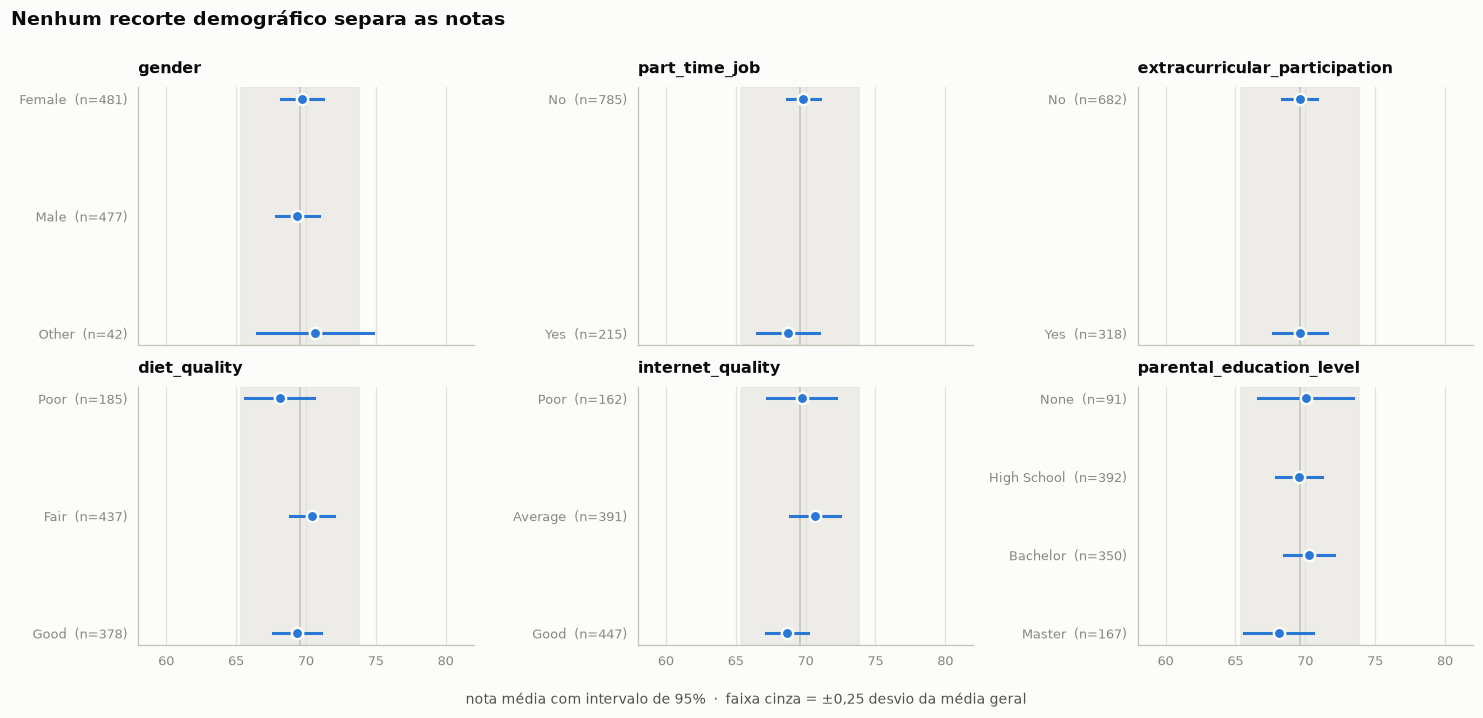

In [6]:
fig, eixos = plt.subplots(2, 3, figsize=(13.5, 6.4), sharex=True)

media_geral = alvo.mean()

for ax, coluna in zip(eixos.flat, GRUPOS):
    sub = grupos[grupos["variavel"] == coluna].iloc[::-1]
    y = np.arange(len(sub))

    # Faixa de ±0,25 desvio em volta da média geral, como régua: diferença que
    # não sai dela é pequena demais para orientar qualquer ação.
    ax.axvspan(media_geral - 0.25 * dp_nota, media_geral + 0.25 * dp_nota,
               color=COR["grade"], alpha=0.55, zorder=0)
    ax.axvline(media_geral, color=COR["eixo"], linewidth=1, zorder=1)

    for i, linha in enumerate(sub.itertuples()):
        ax.plot([linha.ic_baixo, linha.ic_alto], [i, i], color=COR["serie_1"],
                linewidth=2, zorder=2)
        ax.scatter(linha.media, i, s=55, color=COR["serie_1"],
                   edgecolor=COR["superficie"], linewidth=1.6, zorder=3)

    ax.set_yticks(y, [f"{g}  (n={n})" for g, n in zip(sub["grupo"], sub["n"])],
                  fontsize=8.5)
    ax.set_title(coluna)
    ax.set_xlim(58, 82)
    so_grade(ax, eixo="x")

fig.suptitle("Nenhum recorte demográfico separa as notas",
             x=0.005, ha="left", fontsize=12.5, fontweight="bold", y=1.0)
fig.supxlabel("nota média com intervalo de 95%  ·  faixa cinza = ±0,25 desvio da média geral",
              fontsize=9, color=COR["tinta_2"])
plt.tight_layout()
plt.show()

**Não há diferença entre grupos.** Todas as médias caem dentro da faixa cinza, que tem meio desvio-padrão de largura, e em cada painel os intervalos se sobrepõem entre si. A única barra que escapa um pouco da faixa é a de `gender == "Other"`, e ela escapa por ser larga: são 42 alunos, então o intervalo é grande por falta de amostra, não por diferença de desempenho.

Em números, a distância entre o melhor e o pior grupo de cada variável:

| Variável | Amplitude | Em desvios |
|---|---|---|
| `diet_quality` | 2,30 pts | 0,14 |
| `parental_education_level` | 2,19 pts | 0,13 |
| `internet_quality` | 2,00 pts | 0,12 |
| `gender` | 1,28 pts | 0,08 |
| `part_time_job` | 1,09 pts | 0,06 |
| `extracurricular_participation` | 0,03 pts | 0,00 |

Duas observações que fecham a questão.

**As maiores "diferenças" não têm ordem.** Em `diet_quality`, quem come *Fair* tira mais que quem come *Good*. Em `internet_quality`, *Average* supera *Good* e *Poor*. Se houvesse efeito real, ele apareceria como gradiente, não como zigue-zague. Isso é ruído amostral com cara de achado.

**`gender` merece nota à parte** porque é o recorte que mais gera pergunta. A diferença entre os três grupos é de 1,28 ponto, menos de um décimo de desvio, com intervalos que se cobrem quase inteiros. E o grupo *Other* tem 42 alunos, de forma que seu intervalo é largo por construção. **Não há evidência de diferença de desempenho por gênero nesta base**, e reportar os 70,65 do grupo *Other* como "melhor desempenho" seria irresponsável.

### A exceção: saúde mental

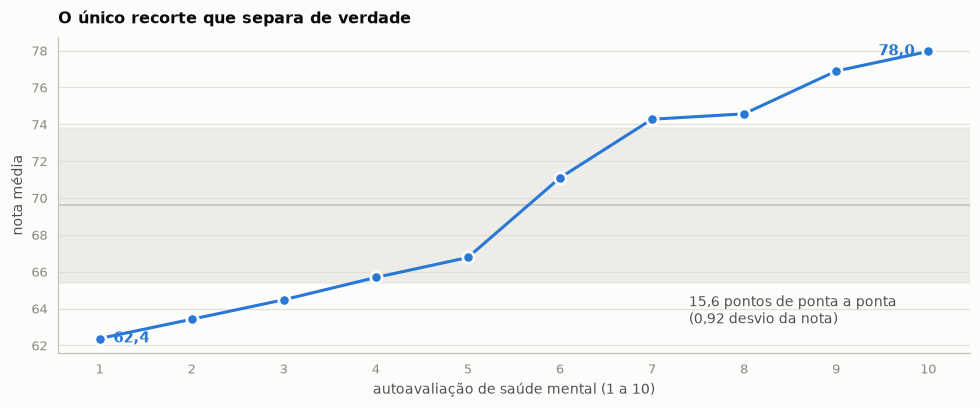

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.8))

por_nota = alvo.groupby(df["mental_health_rating"]).agg(["size", "mean"])
x = por_nota.index.to_numpy()

ax.axhspan(media_geral - 0.25 * dp_nota, media_geral + 0.25 * dp_nota,
           color=COR["grade"], alpha=0.55, zorder=0)
ax.axhline(media_geral, color=COR["eixo"], linewidth=1, zorder=1)

ax.plot(x, por_nota["mean"], color=COR["serie_1"], linewidth=2, zorder=2)
ax.scatter(x, por_nota["mean"], s=55, color=COR["serie_1"],
           edgecolor=COR["superficie"], linewidth=1.8, zorder=3)

amplitude_sm = por_nota["mean"].max() - por_nota["mean"].min()

# Rótulo nas duas pontas em vez de seta: qualquer seta até o topo da curva
# cruzaria a própria linha.
for posicao, alinhamento, desloc in [(0, "left", 0.15), (-1, "right", -0.15)]:
    ax.text(x[posicao] + desloc, por_nota["mean"].iloc[posicao],
            f"{por_nota['mean'].iloc[posicao]:.1f}".replace(".", ","),
            va="center", ha=alinhamento, fontsize=9.5, fontweight="bold",
            color=COR["serie_1"])

ax.text(7.4, 63.2,
        f"{amplitude_sm:.1f} pontos de ponta a ponta\n({amplitude_sm / dp_nota:.2f} desvio da nota)".replace(".", ","),
        fontsize=9, color=COR["tinta_2"])

ax.set_xticks(x)
ax.set_xlabel("autoavaliação de saúde mental (1 a 10)")
ax.set_ylabel("nota média")
ax.set_title("O único recorte que separa de verdade")
so_grade(ax)
plt.tight_layout()
plt.show()

Saúde mental é o único agrupamento da base com **gradiente monótono e amplitude relevante**: 62,4 na base da escala, 78,0 no topo, uma distância de **15,6 pontos, ou 0,92 desvio-padrão**. Doze vezes maior que a diferença de gênero.

E o gradiente é limpo, sem inversão em nenhum degrau, o que é o oposto do zigue-zague das outras variáveis. Quando um efeito é real, ele se comporta assim.

## 5. Recomendações práticas

Três recomendações, ordenadas pelo que a base sustenta, não pelo que soa bem.

### 1. Priorizar quem estuda menos de 3h por dia

É a faixa em que o retorno é maior e o risco é concreto. Pelo notebook 05: entre os alunos que estudam de 0h a 1h, **100% e 91% ficam abaixo de 60**. Em 2h são 51%, em 3h já são 16%, e de 5h em diante ninguém reprova.

Tirar um aluno de 2h para 3h derruba o risco de reprovação de **51% para 16%**. Nenhuma outra intervenção mensurável nesta base chega perto disso.

In [8]:
# Quantos alunos estão na faixa de maior retorno, e qual o risco deles.
CORTE = 60
faixa = pd.cut(df["study_hours_per_day"], [0, 2, 3, 4, np.inf], right=False,
               labels=["menos de 2h", "2h a 3h", "3h a 4h", "4h ou mais"])

prioridade = pd.DataFrame({
    "alunos": alvo.groupby(faixa, observed=True).size(),
    "nota_media": alvo.groupby(faixa, observed=True).mean(),
    "pct_abaixo_de_60": 100 * alvo.groupby(faixa, observed=True).apply(lambda s: (s < CORTE).mean()),
})
prioridade["pct_da_turma"] = 100 * prioridade["alunos"] / len(df)
prioridade

,alunos,nota_media,pct_abaixo_de_60,pct_da_turma
study_hours_per_day,,,,
menos de 2h,133,45.56,93.98,13.30
2h a 3h,201,59.45,50.75,20.10
3h a 4h,281,69.20,16.37,28.10
4h ou mais,385,83.50,1.82,38.50


**133 alunos, 13,3% da turma, estudam menos de 2h por dia, e 94% deles reprovam.** É esse o grupo que a triagem do notebook 04 encontra e é nele que o esforço rende mais.

### 2. Tratar saúde mental como variável acadêmica, não como assunto paralelo

É o segundo maior efeito (5,6 pontos por desvio), o maior entre os hábitos que uma escola consegue de fato influenciar, e o **único recorte de grupo com diferença real** (15,6 pontos entre as pontas da escala).

Além disso, é a variável que mais cresce quando se compara alunos que estudam o mesmo tanto: de 0,32 para 0,575 de correlação. Entre dois alunos igualmente dedicados, saúde mental é o que mais separa o resultado.

### 3. Tela por lazer é a alavanca comportamental mais acessível

Cada hora a menos vale **2,5 pontos**, e a mediana da turma está em 4,4 horas por dia somando redes sociais e streaming. É a recomendação mais fácil de transformar em combinado concreto, porque não depende de serviço novo nem de diagnóstico.

Duas ressalvas que fazem parte da recomendação:

**O maior número não é a melhor recomendação.** Horas de estudo lidera todas as métricas e é também a mais difícil de mudar por conversa. "Estude mais uma hora por dia" é o conselho que todo aluno em dificuldade já ouviu, e repeti-lo não é intervenção. Por isso saúde mental e tempo de tela aparecem acima nesta lista apesar de terem efeitos menores: elas têm caminho de ação.

**Frequência às aulas quase não importa aqui** (0,090 de correlação, 1,4 ponto por desvio), e isso contraria o senso comum escolar. Registro o achado sem defendê-lo: numa base sintética, a ausência de efeito pode ser artefato de geração e não um fato sobre estudantes.

## 6. O que esta base não permite concluir

Esta seção existe porque um relatório que só afirma é menos útil que um que também delimita.

**Nada aqui estabelece causa.** Todas as medidas são de associação. O simulador do notebook 04 responde "o que o modelo prevê se esse número mudar", não "o que acontece se o aluno mudar de hábito".

**Os hábitos desta base são independentes entre si**, com correlação máxima de 0,072 entre 89 pares. Em estudantes reais eles vêm em pacote: quem dorme mal costuma estudar menos e usar mais tela à noite. Isso significa que os efeitos aqui estão limpos de uma forma que a realidade não oferece, e que uma intervenção real mexeria em várias variáveis ao mesmo tempo.

**A base é sintética.** Distribuições suaves, três variáveis quase uniformes, zero duplicata, zero valor fora de domínio e zero rótulo inconsistente. O notebook 01 já tinha levantado a suspeita e cada notebook seguinte acrescentou evidência. As conclusões valem como exercício analítico, e não como achado sobre estudantes reais.

**A nota está censurada no topo.** 48 alunos com exatamente 100, o que atenua todas as correlações relatadas. Os números deste projeto são piso, não valor exato, e o notebook 03 mostrou que descartar esses alunos piora a estimativa em vez de corrigi-la.

## 7. O projeto inteiro, em uma página

| Notebook | Objetivo |
|---|---|
| [01 Exploração](01_exploracao_inicial.ipynb) | A base é confiável? |
| [02 Engenharia](02_engenharia_de_dados.ipynb) | Que variáveis criar? |
| [03 Estatística](03_analise_estatistica.ipynb) | O que explica a nota? |
| [04 Aplicação](04_aplicacao_pratica.ipynb) | O que dá para fazer? |
| [05 Visualização](05_visualizacao.ipynb) | Como comunicar? |
| 06 Síntese | Há diferença entre grupos? |

### As três perguntas da tarefa

**Quais hábitos mais afetam as notas?** Horas de estudo, muito à frente (14,1 pontos por desvio). Depois saúde mental (5,6) e tempo de tela (-3,9). Entre alunos que estudam o mesmo tanto, a ordem se inverte em importância prática: saúde mental e tela passam a ser o que separa.

**Que recomendações surgem?** Priorizar quem estuda menos de 3h, tratar saúde mental como variável acadêmica, e negociar tempo de tela. Nessa ordem, que considera alcance de ação e não só tamanho de efeito.

**Há diferença entre grupos?** Não, com uma exceção. Gênero, trabalho de meio período, atividade extracurricular, dieta, internet e escolaridade dos pais não separam as notas: todas as amplitudes ficam abaixo de 0,15 desvio, e as maiores nem sequer são monótonas. A única exceção é saúde mental, com 0,92 desvio entre as pontas.

### O que foi construído

Seis notebooks e um app em [`app.py`](../app.py), onde a análise vira ferramenta. As conclusões desta tarefa não ficaram só no texto: a aba **Insights** do app deixa quem usa testar qualquer recorte por conta própria, em vez de aceitar a minha palavra de que nenhum separa as notas.

![Aba Insights do app](../assets/img/app-insights.png)

O seletor de recorte é a peça que importa. "Há diferença entre grupos?" é a pergunta que mais convida a pescar resultado, e a resposta mais útil não é a minha conclusão: é o instrumento que permite conferi-la em qualquer corte, com a faixa de referência sempre desenhada junto.